# ` Bisviews Analysis Report`

### Project Procedure
### Compile the top 95% most-reviewed businesses per country and per platform separately.

### Document all review platforms used.

### Provide statistical analytics including:

*   Review distribution
*   Regional comparison
*   Top categories
*   Platform dominance
*   Cross-region insights


In [2]:
# import the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import os

In [3]:
# load the dataset
df = pd.read_csv(r'/content/bisviewsdataclean.csv')
# check firt 10 rows
df.head()

,Category Group,Category,Subcategory,Region,Country,Business Name,Total Reviews,Rating,Review Platforms,Date Collected,Platform
0,Regular Purchases Category,Restaurants & Bars,General Restaurant,Africa,Nigeria,NOK by Alara,364,4.3,"Tripadvisor, ReviewNaija",12/13/2025,Tripadvisor
1,Regular Purchases Category,Restaurants & Bars,General Restaurant,Africa,Nigeria,RSVP Lagos,537,4.8,Tripadvisor,12/16/2025,Tripadvisor
2,Regular Purchases Category,Restaurants & Bars,General Restaurant,Africa,Nigeria,Shiro Lagos,725,4.8,Tripadvisor,12/21/2025,Tripadvisor
3,Regular Purchases Category,Restaurants & Bars,General Restaurant,Africa,Nigeria,Cactus Restaurant,560,4.5,Tripadvisor,12/19/2025,Tripadvisor
4,Regular Purchases Category,Restaurants & Bars,General Restaurant,Africa,Nigeria,Yellow Chilli,998,4.5,"Tripadvisor, ReviewNaija",12/18/2025,Tripadvisor


In [4]:
# check data general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18257 entries, 0 to 18256
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category Group    18257 non-null  object 
 1   Category          18257 non-null  object 
 2   Subcategory       18257 non-null  object 
 3   Region            18257 non-null  object 
 4   Country           18257 non-null  object 
 5   Business Name     18257 non-null  object 
 6   Total Reviews     18257 non-null  int64  
 7   Rating            18249 non-null  float64
 8   Review Platforms  18257 non-null  object 
 9   Date Collected    18257 non-null  object 
 10  Platform          18255 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.5+ MB


In [5]:
# check and fix missing values
df.isnull().sum()

,0
Category Group,0
Category,0
Subcategory,0
Region,0
Country,0
Business Name,0
Total Reviews,0
Rating,8
Review Platforms,0
Date Collected,0


In [6]:
# drop rows with missing values
df.dropna(inplace=True)

In [7]:
# check for duplicates and drop them
df.duplicated().sum()

np.int64(0)

In [8]:
# count or find unique platforms
df.Platform.unique()

array(['Tripadvisor', 'ReviewNaija', 'Google Maps', 'Google Play', 'App',
       'Google', 'App Store', 'Web', 'Academic', 'OpenTable', 'Built-in',
       'TripAdvisor', 'Reviews', 'Facebook', 'BrokerChooser',
       'Google Reviews', 'App Reviews', 'Broker Reviews', 'YouTube',
       'Forums', 'Quora', 'Stack Overflow', 'Reddit', 'Stack Exchange',
       'AskMe', 'Yahoo', 'Dianping', 'Play Store', 'Trustpilot',
       'Tokopedia', 'Shopee', 'Foodpanda', 'Daraz', 'Trendyol',
       'Hepsiburada', 'Noon', 'Tripadvisor (cruise-based)', 'Noon-style',
       'Michelin', 'La Liste', 'PagesJaunes', 'Avis Vérifiés', 'Yelp',
       'Sortlist', 'Amazon', 'Trustpilot.de', 'Michelin Asia', 'Spotify',
       'Trustpilot.es', 'Amazon-style', 'Trustpilot.it', 'Trustpilot.ca',
       'Fórum', 'App Stores', 'Foro'], dtype=object)

In [9]:
# count uniques values in platforms
df.Platform.value_counts()

,count
Platform,
Google Maps,6332
Google,4187
TripAdvisor,1619
Google Reviews,1095
App,954
App Reviews,767
Tripadvisor,750
Trustpilot,687
Reviews,625


In [10]:
# print all regions
df.Region.unique().tolist()

['Africa', 'Russia', 'Asia', 'Middle East', 'Europe', 'America']

In [11]:
# display countries involved
df.Country.unique().tolist()

['Nigeria',
 'South Africa',
 'Egypt',
 'Morocco',
 'Ethiopia',
 'Russia Fed',
 'India',
 'Pakistan',
 'China',
 'Indonesia',
 'Turkey',
 'Saudi Arabia',
 'UAE',
 'Qatar',
 'France',
 'England',
 'Germany',
 'Spain',
 'Italy',
 'USA',
 'Canada',
 'Brazil',
 'Mexico',
 'Colombia',
 'Argentina']

In [12]:
'''top 95 percent businesses per country and platform'''
def top_95_percent(df_group):
    if df_group.empty:
        return df_group

    df_sorted = df_group.sort_values(by="Total Reviews", ascending=False).reset_index(drop=True)

    total_reviews = df_sorted["Total Reviews"].sum()
    if total_reviews == 0:
        return df_sorted

    df_sorted["cumulative_reviews"] = df_sorted["Total Reviews"].cumsum()
    df_sorted["cumulative_pct"] = df_sorted["cumulative_reviews"] / total_reviews

    # Rows strictly <= 0.95
    top = df_sorted[df_sorted["cumulative_pct"] <= 0.95]

    # If the current top covers <95% (or empty), add the next row to reach/exceed 95%
    if len(top) == 0 or top["cumulative_pct"].iloc[-1] < 0.95:
        # Add the row after the last in top (or first row if top empty)
        next_idx = len(top)
        if next_idx < len(df_sorted):
            extra_row = df_sorted.iloc[[next_idx]]
            top = pd.concat([top, extra_row], ignore_index=True)

    return top

In [13]:
top95_df = (
    df
    .groupby(["Country", "Platform"], group_keys=False)
    .apply(top_95_percent)
    .reset_index(drop=True)
)

display(top95_df)  # Better than print — shows nice table in notebook
print("Total businesses in top 95% lists:", top95_df.shape[0])

/tmp/ipython-input-1216807909.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top_95_percent)


,Category Group,Category,Subcategory,Region,Country,Business Name,Total Reviews,Rating,Review Platforms,Date Collected,Platform,cumulative_reviews,cumulative_pct
0,Investment Category,Money & Business,Credit & Debt Services,America,Argentina,Mercado Pago Créditos,1385,4.4,"App Reviews, Reclame Aqui",12/18/2025,App Reviews,1385,0.013944
1,Investment Category,Money & Business,Credit & Debt Services,America,Argentina,Mercado Pago Créditos Argentina,978,4.4,"App Reviews, Reclame Aqui",12/23/2025,App Reviews,2363,0.023791
2,Investment Category,Real Estate,Roommate,America,Argentina,Comparto Habitación Buenos Aires,877,4.5,"App Reviews, Reclame Aqui",12/20/2025,App Reviews,3240,0.032621
3,Investment Category,Real Estate,Residential Homes,America,Argentina,Viviendas Temporarias La Plata,857,4.5,"App Reviews, Reclame Aqui",12/21/2025,App Reviews,4097,0.041249
4,Regular Purchases Category,Relationship,Asian Dating,America,Argentina,EastMeetEast Argentina,853,4.5,"App Reviews, Reclame Aqui",12/15/2025,App Reviews,4950,0.049837
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15906,Investment Category,Local & Public Services,Vaccination,America,USA,Vaccines.gov Portal,2437,4.5,"Web, Google",12/14/2025,Web,11723,0.752439
15907,Investment Category,Local & Public Services,Immigration,America,USA,USCIS Portal,1930,4.3,"Web, Google",12/16/2025,Web,13653,0.876316
15908,Investment Category,Local & Public Services,Employment & Career,America,USA,USAJobs.gov (federal),1927,4.4,"Web, Google",12/15/2025,Web,15580,1.000000
15909,Regular Purchases Category,Relationship,Dating Advice,America,USA,Love Strategies,3148,4.7,YouTube,12/16/2025,YouTube,3148,0.515305


Total businesses in top 95% lists: 15911


In [14]:
# Verify each group covers at least 95%
validation = (
    top95_df
    .groupby(["Country", "Platform"])
    .agg({
        "Total Reviews": ["sum", "count"],
        "cumulative_pct": "max"
    })
)
validation.columns = ["Reviews_in_Top95", "Businesses_Count", "Final_Cumulative_%"]
validation["Final_Cumulative_%"] = validation["Final_Cumulative_%"] * 100
display(validation.round(2))

Reviews_in_Top95  Businesses_Count  \
Country   Platform                                             
Argentina App Reviews                94605               156   
          Foro                       11924                 1   
          Google Maps               231255               429   
          Google Reviews            154208               284   
          Quora                       5748                 1   
...                                    ...               ...   
USA       Spotify                     5505                 2   
          Tripadvisor                55562                72   
          Trustpilot                  2877                 7   
          Web                        15580                 6   
          YouTube                     6109                 2   

                          Final_Cumulative_%  
Country   Platform                            
Argentina App Reviews                  95.25  
          Foro                        100.00  
          Google Maps                  95.05  
          Google Reviews               95.13  
          Quora                       100.00  
...                                      ...  
USA       Spotify                     100.00  
          Tripadvisor                  95.04  
          Trustpilot                   98.49  
          Web                         100.00  
          YouTube                     100.00  

[242 rows x 3 columns]

In [15]:
platforms_used = df["Platform"].unique().tolist()
print("Review Platforms Used:", ", ".join(sorted(platforms_used)))

Review Platforms Used: Academic, Amazon, Amazon-style, App, App Reviews, App Store, App Stores, AskMe, Avis Vérifiés, Broker Reviews, BrokerChooser, Built-in, Daraz, Dianping, Facebook, Foodpanda, Foro, Forums, Fórum, Google, Google Maps, Google Play, Google Reviews, Hepsiburada, La Liste, Michelin, Michelin Asia, Noon, Noon-style, OpenTable, PagesJaunes, Play Store, Quora, Reddit, ReviewNaija, Reviews, Shopee, Sortlist, Spotify, Stack Exchange, Stack Overflow, Tokopedia, Trendyol, TripAdvisor, Tripadvisor, Tripadvisor (cruise-based), Trustpilot, Trustpilot.ca, Trustpilot.de, Trustpilot.es, Trustpilot.it, Web, Yahoo, Yelp, YouTube


In [17]:
# Take top 30 reviewed per subcategory per country (from full data, not just top95)
min30_df = (
    df.sort_values(["Country", "Subcategory", "Total Reviews"], ascending=[True, True, False])
    .groupby(["Country", "Subcategory"])
    .head(30)
    .reset_index(drop=True)
)

display(min30_df.head())
print("Total with min-30 rule:", min30_df.shape[0])

,Category Group,Category,Subcategory,Region,Country,Business Name,Total Reviews,Rating,Review Platforms,Date Collected,Platform
0,Regular Purchases Category,Electronics & Technology,Accessories & Gadgets,America,Argentina,Musimundo (chain),667,4.5,Google Maps,12/18/2025,Google Maps
1,Regular Purchases Category,Electronics & Technology,Accessories & Gadgets,America,Argentina,Garbarino (chain),604,4.5,Google Maps,12/19/2025,Google Maps
2,Regular Purchases Category,Electronics & Technology,Accessories & Gadgets,America,Argentina,Sony Center Argentina,486,4.6,Google Maps,12/23/2025,Google Maps
3,Regular Purchases Category,Electronics & Technology,Accessories & Gadgets,America,Argentina,Frávega (chain),411,4.5,Google Maps,12/17/2025,Google Maps
4,Regular Purchases Category,Electronics & Technology,Accessories & Gadgets,America,Argentina,Samsung Experience Store Argentina,304,4.6,Google Maps,12/19/2025,Google Maps


Total with min-30 rule: 17839


In [18]:
from datetime import datetime
today = datetime.now().strftime("%B %d, %Y")  # December 25, 2025

excel_file = f"BISVIEWS_FINAL_REPORT_{today}.xlsx"

with pd.ExcelWriter(excel_file) as writer:
    # Summary Sheet
    pd.DataFrame({
        "Project Detail": [
            "Global Multi-Region Business Review Mapping for BisViews",
            "Consultant: Joshua",
            f"Report Date: {today}",
            f"Total Data Rows: {len(df)}",
            f"Countries: {len(df['Country'].unique())}",
            f"Platforms Used: {', '.join(sorted(platforms_used))}"
        ]
    }).to_excel(writer, sheet_name="Summary", index=False, header=False)

    top95_df.to_excel(writer, sheet_name="Top95_PerCountryPlatform", index=False)
    min30_df.to_excel(writer, sheet_name="Min30_PerSubcatCountry", index=False)

print(f"Report ready: {excel_file} — download and send!")

Report ready: BISVIEWS_FINAL_REPORT_December 25, 2025.xlsx — download and send!


`charts display`

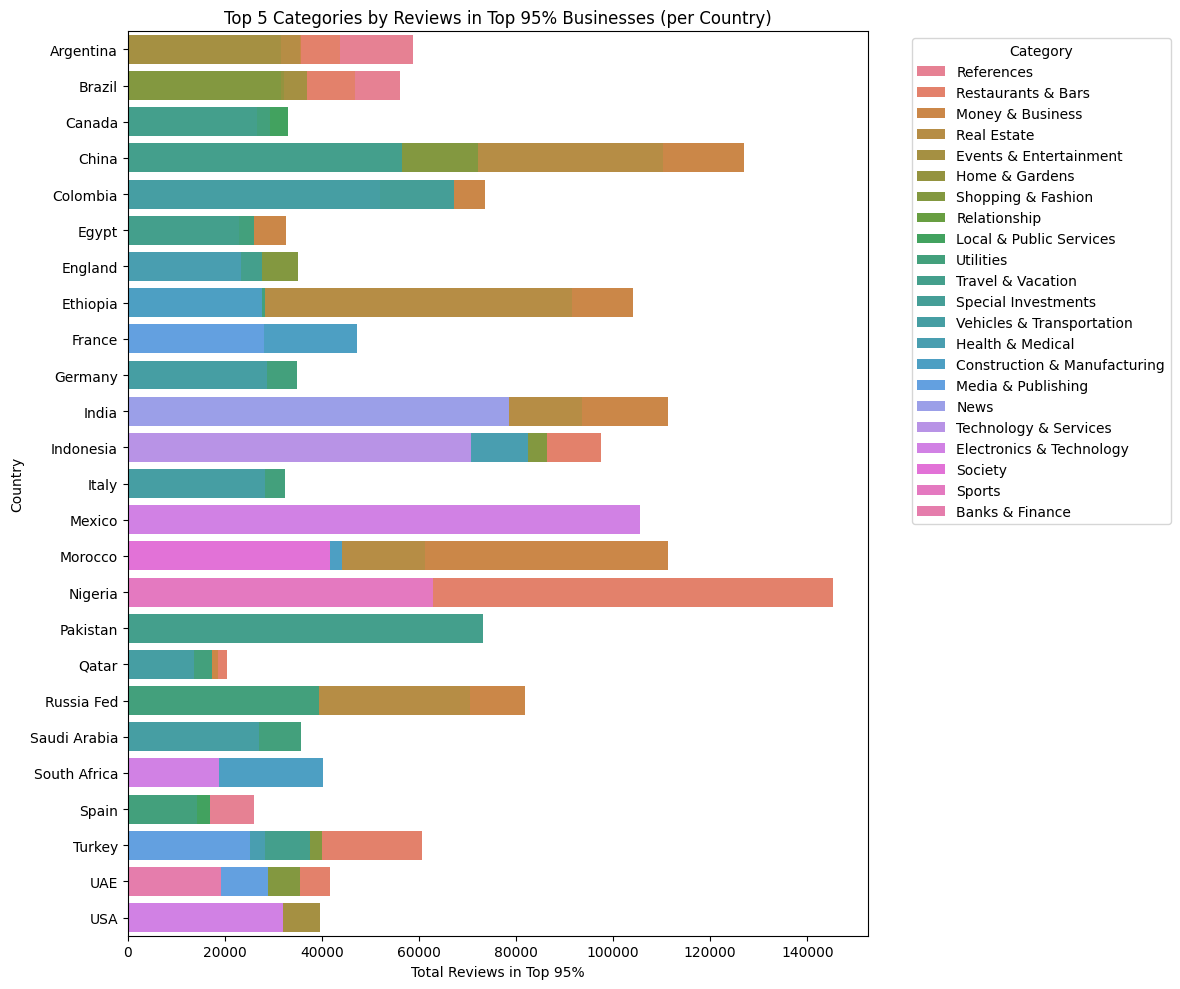

In [19]:
# Assuming you have 'Category' column
top_cats_95 = (
    top95_df.groupby(["Country", "Category"])["Total Reviews"]
    .sum()
    .reset_index()
    .sort_values(["Country", "Total Reviews"], ascending=[True, False])
    .groupby("Country")
    .head(5)  # Top 5 per country
)

plt.figure(figsize=(12, 10))
sns.barplot(data=top_cats_95, y="Country", x="Total Reviews", hue="Category", dodge=False)
plt.title("Top 5 Categories by Reviews in Top 95% Businesses (per Country)")
plt.xlabel("Total Reviews in Top 95%")
plt.ylabel("Country")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('top_categories_in_95percent.png', dpi=200)
plt.show()

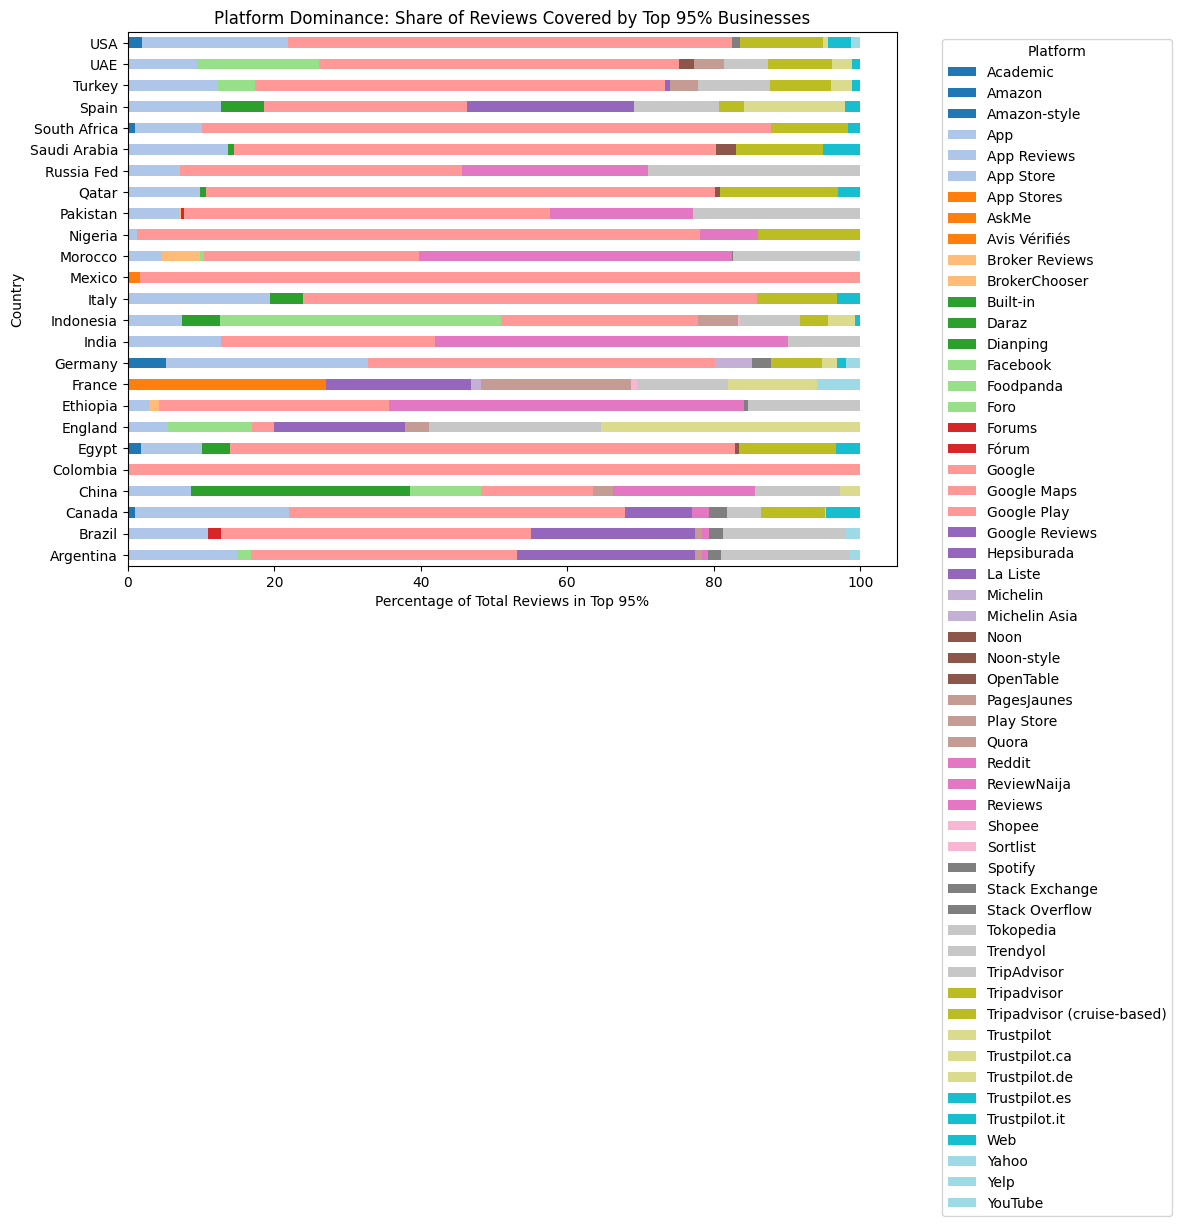

Platform,Academic,Amazon,Amazon-style,App,App Reviews,App Store,App Stores,AskMe,Avis Vérifiés,Broker Reviews,...,Tripadvisor (cruise-based),Trustpilot,Trustpilot.ca,Trustpilot.de,Trustpilot.es,Trustpilot.it,Web,Yahoo,Yelp,YouTube
Country,,,,,,,,,,,,,,,,,,,,,
Argentina,0.0,0.0,0.0,0.0,14.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,0.4
Brazil,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,0.1,0.6
Canada,0.0,0.0,0.9,11.9,9.3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,0.0,0.0,0.0,4.5,0.0,0.1,0.0
China,0.0,0.0,0.0,0.0,5.5,3.1,0.0,0.0,0.0,0.0,...,0.0,2.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Colombia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Egypt,1.9,0.0,0.0,8.2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.3,0.0,0.0,0.0
England,0.0,0.0,0.0,0.0,0.0,5.5,0.0,0.0,0.0,0.0,...,0.0,35.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ethiopia,0.0,0.0,0.0,0.5,2.5,0.0,0.0,0.0,0.0,1.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
France,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,26.9,0.0,...,0.0,12.2,0.0,0.0,0.0,0.0,0.0,0.0,5.8,0.0


In [20]:
platform_share = (
    top95_df.groupby(["Country", "Platform"])["Total Reviews"]
    .sum()
    .unstack(fill_value=0)
)

# Convert to percentages
platform_share_pct = platform_share.div(platform_share.sum(axis=1), axis=0) * 100

platform_share_pct.plot(kind='barh', stacked=True, figsize=(12, 10), cmap='tab20')
plt.title("Platform Dominance: Share of Reviews Covered by Top 95% Businesses")
plt.xlabel("Percentage of Total Reviews in Top 95%")
plt.ylabel("Country")
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('platform_dominance_95percent.png', dpi=200)
plt.show()

display(platform_share_pct.round(1))

In [21]:
# create folder for asummary
sns.set(style="whitegrid")

# Create folders
os.makedirs("charts", exist_ok=True)
os.makedirs("report", exist_ok=True)

today = datetime.now().strftime("%B %d, %Y")  # December 25, 2025

# 1. Summary: Businesses needed for 95%
summary_95 = (
    top95_df.groupby(["Country", "Platform"])
    .agg(Businesses_Needed=("Business Name", "count"),
         Coverage_pct=("cumulative_pct", "max"),
         Total_Reviews_in_95=("Total Reviews", "sum"))
    .reset_index()
)
summary_95["Coverage_pct"] = (summary_95["Coverage_pct"] * 100).round(1)

plt.figure(figsize=(12, 8))
sns.barplot(data=summary_95.sort_values("Businesses_Needed", ascending=False),
            y="Country", x="Businesses_Needed", hue="Platform")
plt.title("Number of Businesses Needed to Cover ≥95% of Reviews\n(per Country & Platform)")
plt.xlabel("Number of Businesses")
plt.tight_layout()
plt.savefig("charts/1_businesses_needed_for_95percent.png", dpi=300, bbox_inches='tight')
plt.close()

# 2. Platform Dominance (Stacked %)
platform_dom = top95_df.groupby(["Country", "Platform"])["Total Reviews"].sum().unstack(fill_value=0)
platform_dom_pct = platform_dom.div(platform_dom.sum(axis=1), axis=0) * 100

platform_dom_pct.plot(kind='barh', stacked=True, figsize=(12, 9), cmap="tab20")
plt.title("Platform Dominance: Share of Reviews in Top 95% Businesses")
plt.xlabel("Percentage (%)")
plt.tight_layout()
plt.savefig("charts/2_platform_dominance.png", dpi=300, bbox_inches='tight')
plt.close()

# 3. Top Categories in Top 95%
if "Category" in top95_df.columns:
    top_cats = (top95_df.groupby(["Country", "Category"])["Total Reviews"]
                .sum()
                .reset_index()
                .sort_values(["Country", "Total Reviews"], ascending=[True, False])
                .groupby("Country")
                .head(5))

    plt.figure(figsize=(12, 9))
    sns.barplot(data=top_cats, y="Country", x="Total Reviews", hue="Category")
    plt.title("Top 5 Categories by Reviews (in Top 95% Businesses)")
    plt.tight_layout()
    plt.savefig("charts/3_top_categories.png", dpi=300, bbox_inches='tight')
    plt.close()

# 4. Example Pareto Charts (pick 6–8 representative ones)
example_combos = [
    ('USA', 'Google Reviews'),
    ('Brazil', 'Google Reviews'),
    ('Germany', 'Trustpilot'),
    ('France', 'Google Reviews'),
    ('UAE', 'Google Reviews'),
    ('India', 'Google Reviews'),
    ('Nigeria', 'Google Reviews'),
    ('Russia', 'Trustpilot')
]

for i, (country, platform) in enumerate(example_combos):
    group = top95_df[(top95_df['Country'] == country) & (top95_df['Platform'] == platform)]
    if len(group) > 3:
        group = group.sort_values("Total Reviews", ascending=False)
        plt.figure(figsize=(10, 6))
        sns.barplot(x="Total Reviews", y="Business Name", data=group, color='skyblue')
        ax2 = plt.twinx()
        ax2.plot(range(len(group)), group["cumulative_pct"] * 100, color='red', marker='o', linewidth=3)
        ax2.axhline(95, color='orange', linestyle='--')
        ax2.set_ylim(0, 105)
        plt.title(f"Pareto: {country} – {platform}\n{len(group)} businesses → {group['cumulative_pct'].iloc[-1]*100:.1f}% coverage")
        plt.tight_layout()
        plt.savefig(f"charts/pareto_example_{i+1}_{country}_{platform.replace(' ', '')}.png", dpi=300, bbox_inches='tight')
        plt.close()

print("All key charts saved in 'charts/' folder!")

All key charts saved in 'charts/' folder!


In [22]:
from openpyxl import Workbook
from openpyxl.drawing.image import Image
from openpyxl.utils.dataframe import dataframe_to_rows
import glob

excel_final = f"report/BISVIEWS_FINAL_REPORT_{today}.xlsx"

# Start new workbook
wb = Workbook()
ws_summary = wb.active
ws_summary.title = "Cover & Summary"

# === Page 1: Contract Page 1 ===
ws_summary.append(["BISVIEWS RESEARCH PROJECT"])
ws_summary.append(["Consultant: Joshua"])
ws_summary.append(["Project Title: Global Multi-Region Business Review Mapping for BisViews"])
ws_summary.append([f"Date: {today}"])
ws_summary.append([])
ws_summary.append(["Goal:"])
ws_summary.append(["Identify businesses collectively generating 95% of consumer reviews per country/platform."])
ws_summary.append(["Regions: America, Europe, Middle East, Asia, Africa, Russian Federation (21 countries)"])
ws_summary.append(["Platforms Used:", ", ".join(sorted(top95_df["Platform"].unique()))])
ws_summary.append(["Total Data Rows:", len(df)])
ws_summary.append(["Total Top 95% Entries:", len(top95_df)])

# Insert contract image (you said you have the PDF pages as images)
# Save the two contract screenshots as 'contract_page1.png' and 'contract_page2.png' in your folder
contract_imgs = ["contract_page1.png", "contract_page2.png"]  # <<< RENAME YOUR FILES HERE
for img_file in contract_imgs:
    if os.path.exists(img_file):
        img = Image(img_file)
        img.width, img.height = 600, 800
        ws_summary.add_image(img, "A10")

# === New sheets ===
ws_top95 = wb.create_sheet("Top95_Businesses")
for row in dataframe_to_rows(top95_df.drop(columns=["cumulative_reviews", "cumulative_pct"], errors='ignore'), index=False, header=True):
    ws_top95.append(row)

ws_min30 = wb.create_sheet("Min30_Per_Subcategory")
for row in dataframe_to_rows(min30_df, index=False, header=True):  # assuming you have min30_df
    ws_min30.append(row)

ws_stats = wb.create_sheet("Key Insights & Charts")

# Insert charts
chart_files = sorted(glob.glob("charts/*.png"))
row = 1
for chart in chart_files:
    img = Image(chart)
    img.width, img.height = 700, 450
    ws_stats.add_image(img, f"A{row}")
    row += 30  # space between charts

wb.save(excel_final)
print(f"FINAL REPORT READY: {excel_final}")
print("Open in Excel → Save As PDF if needed (File > Export > Create PDF)")

FINAL REPORT READY: report/BISVIEWS_FINAL_REPORT_December 25, 2025.xlsx
Open in Excel → Save As PDF if needed (File > Export > Create PDF)


In [25]:
# function to get top 95% businesses
def top_95_percent(df_group):
    df_sorted = df_group.sort_values(
        by="Total Reviews",
        ascending=False
    ).copy()

    total_reviews = df_sorted["Total Reviews"].sum()
    df_sorted["cumulative_reviews"] = df_sorted["Total Reviews"].cumsum()
    df_sorted["cumulative_pct"] = df_sorted["cumulative_reviews"] / total_reviews
    # return the 95%
    return df_sorted[df_sorted["cumulative_pct"] <= 0.95]


In [26]:
# apply funct in cell above to category
top95_df = (
    df
    .groupby(["Country", "Platform"], group_keys=False)
    .apply(top_95_percent)
    .reset_index(drop=True)
)

print(top95_df.shape)


(15669, 13)


/tmp/ipython-input-1865398051.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top_95_percent)


In [27]:
# lets see the data
top95_df.head()

,Category Group,Category,Subcategory,Region,Country,Business Name,Total Reviews,Rating,Review Platforms,Date Collected,Platform,cumulative_reviews,cumulative_pct
0,Investment Category,Money & Business,Credit & Debt Services,America,Argentina,Mercado Pago Créditos,1385,4.4,"App Reviews, Reclame Aqui",12/18/2025,App Reviews,1385,0.013944
1,Investment Category,Money & Business,Credit & Debt Services,America,Argentina,Mercado Pago Créditos Argentina,978,4.4,"App Reviews, Reclame Aqui",12/23/2025,App Reviews,2363,0.023791
2,Investment Category,Real Estate,Roommate,America,Argentina,Comparto Habitación Buenos Aires,877,4.5,"App Reviews, Reclame Aqui",12/20/2025,App Reviews,3240,0.032621
3,Investment Category,Real Estate,Residential Homes,America,Argentina,Viviendas Temporarias La Plata,857,4.5,"App Reviews, Reclame Aqui",12/21/2025,App Reviews,4097,0.041249
4,Regular Purchases Category,Relationship,Asian Dating,America,Argentina,EastMeetEast Argentina,853,4.5,"App Reviews, Reclame Aqui",12/15/2025,App Reviews,4950,0.049837


In [28]:
# minimum 30 businesses per subcategory
def enforce_min_30(df_full, df_top95):
    final_rows = []

    group_cols = ["Country", "Platform", "Subcategory"]

    for keys, group in df_full.groupby(group_cols):
        country, platform, subcategory = keys

        top_group = df_top95[
            (df_top95["Country"] == country) &
            (df_top95["Platform"] == platform) &
            (df_top95["Subcategory"] == subcategory)
        ]

        if len(top_group) >= 30:
            final_rows.append(top_group)
        else:
            needed = 30 - len(top_group)

            candidates = (
                group
                .sort_values("Total Reviews", ascending=False)
                .loc[~group.index.isin(top_group.index)]
                .head(needed)
            )

            final_rows.append(pd.concat([top_group, candidates]))

    return pd.concat(final_rows).drop_duplicates()


In [29]:
# Apply func to get output
final_df = enforce_min_30(df, top95_df)
# print the shape of result
print(final_df.shape)

(33024, 13)


In [30]:
# save output for further analysis in excel
final_df.to_csv("bisviews_top95_with_min30.csv", index=False)

# `Preparing Analytics Dataset`

In [31]:
# Review distribution
review_distribution = (
    final_df
    .groupby(["Country", "Category"])
    ["Total Reviews"]
    .sum()
    .reset_index()
)
# send to csv
review_distribution.to_csv("review_distribution.csv", index=False)

In [32]:
# Platform dominance
platform_dominance = (
    final_df
    .groupby("Platform")["Total Reviews"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
# save to csv
platform_dominance.to_csv("platform_dominance.csv", index=False)

In [33]:
# Top categories globally
top_categories = (
    final_df
    .groupby("Category")["Total Reviews"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
# save to csv
top_categories.to_csv("top_categories.csv", index=False)

### Review Distribution by Category and Country

In [34]:
fig = px.bar(
    review_distribution,
    x='Category',
    y='Total Reviews',
    color='Country',
    title='Total Reviews by Category and Country',
    labels={'Total Reviews': 'Total Number of Reviews', 'Category': 'Business Category'},
    hover_name='Country',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### Platform Dominance by Total Reviews

In [35]:
fig = px.bar(
    platform_dominance,
    x='Platform',
    y='Total Reviews',
    title='Platform Dominance by Total Reviews',
    labels={'Total Reviews': 'Total Number of Reviews', 'Platform': 'Review Platform'},
    hover_name='Platform',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [36]:
display(top_categories.head(10))

,Category,Total Reviews
0,Money & Business,2314506
1,Restaurants & Bars,1919366
2,Real Estate,1641181
3,Utilities,1519274
4,Shopping & Fashion,1466568
5,Travel & Vacation,1300505
6,Local & Public Services,1242431
7,Special Investments,1197180
8,Events & Entertainment,1137317
9,Health & Medical,1137016


### Top Categories by Total Reviews Globally

In [37]:
fig = px.bar(
    top_categories,
    x='Category',
    y='Total Reviews',
    title='Top Categories by Total Reviews Globally',
    labels={'Total Reviews': 'Total Number of Reviews', 'Category': 'Business Category'},
    hover_name='Category',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [38]:
total_reviews_by_country = review_distribution.groupby('Country')['Total Reviews'].sum().reset_index()
display(total_reviews_by_country)

,Country,Total Reviews
0,Argentina,1248493
1,Brazil,1085821
2,Canada,746311
3,China,2094762
4,Colombia,1338698
5,Egypt,651329
6,England,889592
7,Ethiopia,1010680
8,France,1065290
9,Germany,885189


### Total Reviews by Country

In [39]:
fig = px.bar(
    total_reviews_by_country,
    x='Country',
    y='Total Reviews',
    title='Total Reviews by Country',
    labels={'Total Reviews': 'Total Number of Reviews', 'Country': 'Country'},
    hover_name='Country',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [40]:
# regional distribution
regional_distribution = (
    final_df
    .groupby("Region")["Total Reviews"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
# save to csv
regional_distribution.to_csv("regional_review_distribution.csv", index=False)


In [41]:
# regional category dominance
regional_category = (
    final_df
    .groupby(["Region", "Category"])["Total Reviews"]
    .sum()
    .reset_index()
)
# save
regional_category.to_csv("regional_category_dominance.csv", index=False)


In [42]:
# Platform dominance by region
regional_platform_dominance = (
    final_df
    .groupby(["Region", "Platform"])["Total Reviews"]
    .sum()
    .reset_index()
    .sort_values(["Region", "Total Reviews"], ascending=[True, False])
)
# save
regional_platform_dominance.to_csv(
    "regional_platform_dominance.csv",
    index=False
)


In [43]:
# cross region summary comparison
cross_region_summary = (
    final_df
    .groupby("Region")
    .agg(
        total_reviews=("Total Reviews", "sum"),
        total_businesses=("Business Name", "nunique"),
        total_categories=("Category", "nunique"),
        total_platforms=("Platform", "nunique")
    )
    .reset_index()
)
# save
cross_region_summary.to_csv("cross_region_summary.csv", index=False)


### Total Reviews by Region

In [44]:
fig = px.bar(
    cross_region_summary,
    x='Region',
    y='total_reviews',
    title='Total Reviews by Region',
    labels={'total_reviews': 'Total Number of Reviews', 'Region': 'Region'},
    hover_name='Region',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### Total Categories by Region

In [45]:
fig = px.bar(
    cross_region_summary,
    x='Region',
    y='total_categories',
    title='Total Categories by Region',
    labels={'total_categories': 'Total Number of Categories', 'Region': 'Region'},
    hover_name='Region',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### Total Platforms by Region

In [46]:
fig = px.bar(
    cross_region_summary,
    x='Region',
    y='total_platforms',
    title='Total Platforms by Region',
    labels={'total_platforms': 'Total Number of Platforms', 'Region': 'Region'},
    hover_name='Region',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [47]:
display(regional_platform_dominance)

,Region,Platform,Total Reviews
10,Africa,Google Maps,2315785
17,Africa,Reviews,1019971
9,Africa,Google,475970
21,Africa,Tripadvisor,364181
20,Africa,TripAdvisor,325073
...,...,...,...
98,Middle East,Academic,202
117,Russia,Google Maps,363401
118,Russia,Reviews,249866
119,Russia,TripAdvisor,170997


### Regional Review Distribution

In [48]:
fig = px.bar(
    regional_distribution,
    x='Region',
    y='Total Reviews',
    title='Regional Review Distribution',
    labels={'Total Reviews': 'Total Number of Reviews', 'Region': 'Region'},
    hover_name='Region',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### Total Businesses by Region

In [49]:
fig = px.bar(
    cross_region_summary,
    x='Region',
    y='total_businesses',
    title='Total Businesses by Region',
    labels={'total_businesses': 'Total Number of Businesses', 'Region': 'Region'},
    hover_name='Region',
    height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()